In [58]:
import pandas as pd
from tqdm.auto import tqdm
import time

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/Fraud Detection Dataset.csv')

# View the first 5 rows
print(df.head())

    transaction_id                  timestamp  customer_id        card_id  \
0  TXN000000000001  2025-10-19T07:46:29+00:00  CUST0018039  CARD0018039-2   
1  TXN000000000002  2025-06-29T01:09:39+00:00  CUST0040966  CARD0040966-2   
2  TXN000000000003  2025-07-06T10:28:29+00:00  CUST0055324  CARD0055324-2   
3  TXN000000000004  2025-01-26T01:49:36+00:00  CUST0023733  CARD0023733-3   
4  TXN000000000005  2025-06-04T11:27:59+00:00  CUST0039805  CARD0039805-1   

      device_id      ip_address merchant_id merchant_category  \
0  ef4bb478f96c   165.185.21.33   MID003362       restaurants   
1  d57986988353   147.24.150.17   MID014052       electronics   
2  5cb8294a9726   211.23.48.192   MID018641           fashion   
3  3449ec767cf7  136.82.124.111   MID004962           fashion   
4  56e9c34ba51c    82.46.29.202   MID009699          pharmacy   

  merchant_country    merchant_city  merchant_latitude  merchant_longitude  \
0               CA       Taylorberg         -58.474226          116.

In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy.stats import f_oneway, chi2_contingency

def run_comprehensive_eda(file_path):
    sns.set_theme(style="whitegrid")

    # 1. Load the Data
    print(f"Loading dataset from: {file_path}")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        # If a directory is provided instead of a file, find the first CSV
        csv_files = [f for f in os.listdir(file_path) if f.endswith('.csv')]
        if not csv_files:
            print("No CSV files found in the specified path.")
            return
        df = pd.read_csv(os.path.join(file_path, csv_files[0]))

    print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    # Convert timestamp to datetime
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # 2. Fraud to Non-Fraud Ratio (Primary Request)
    print(f"\n{'='*40}\n1. Fraud to Non-Fraud Ratio\n{'='*40}")
    if 'is_fraud' in df.columns:
        fraud_counts = df['is_fraud'].value_counts()
        fraud_ratio = df['is_fraud'].mean() * 100

        print(f"Total Non-Fraudulent (0): {fraud_counts.get(0, 0)}")
        print(f"Total Fraudulent (1): {fraud_counts.get(1, 0)}")
        print(f"Overall Fraud Prevalence: {fraud_ratio:.4f}%\n")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Bar Chart
        sns.countplot(data=df, x='is_fraud', palette=['#004488', '#D95319'], ax=axes[0])
        axes[0].set_title('Count of Fraud vs Non-Fraud Transactions')

        # Pie Chart for visual proportion
        axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
                    colors=['#004488', '#D95319'], startangle=90, explode=(0, 0.1))
        axes[1].set_title('Proportion of Fraudulent Transactions')

        plt.tight_layout()
        plt.show()

        # If fraud_type exists, show the breakdown of the fraud instances
        if 'fraud_type' in df.columns and fraud_counts.get(1, 0) > 0:
            plt.figure(figsize=(10, 5))
            sns.countplot(data=df[df['is_fraud'] == 1], y='fraud_type', palette='viridis')
            plt.title('Breakdown of Fraud Types')
            plt.tight_layout()
            plt.show()
    else:
        print("Target column 'is_fraud' not found in dataset.")
        return

    # Drop high-cardinality ID columns for remaining visualizations to save memory
    cols_to_drop = ['transaction_id', 'customer_id', 'card_id', 'device_id', 'ip_address', 'merchant_id']
    df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

    # Identify column types
    num_cols = df_clean.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

    if 'is_fraud' in num_cols: num_cols.remove('is_fraud')
    if 'is_fraud' in cat_cols: cat_cols.remove('is_fraud')

    # 3. Numerical Feature Histograms
    print(f"\n{'='*40}\n2. Numerical Distributions\n{'='*40}")
    if num_cols:
        df_clean[num_cols].hist(bins=50, figsize=(15, 5 * ((len(num_cols) + 1) // 2)), color='#004488', layout=(-1, 2))
        plt.suptitle('Histograms of Numerical Features', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

    # 4. Amount Distribution by Fraud Status (Crucial for transaction data)
    if 'amount' in num_cols:
        plt.figure(figsize=(12, 6))
        # Using log scale because transaction amounts are usually highly skewed
        sns.boxplot(data=df_clean, x='is_fraud', y='amount', palette=['#004488', '#D95319'])
        plt.yscale('log')
        plt.title('Transaction Amount Distribution by Fraud Status (Log Scale)')
        plt.show()

    # 5. Categorical Analysis (e.g., Merchant Category, Transaction Type)
    print(f"\n{'='*40}\n3. Categorical Distributions\n{'='*40}")
    key_categories = [col for col in ['merchant_category', 'transaction_type', 'currency'] if col in cat_cols]

    for col in key_categories:
        plt.figure(figsize=(14, 6))
        # Show top 15 categories if there are many
        top_cats = df_clean[col].value_counts().nlargest(15).index
        sns.countplot(data=df_clean[df_clean[col].isin(top_cats)], y=col, hue='is_fraud', palette=['#004488', '#D95319'])
        plt.title(f'Top 15 {col} by Fraud Status')
        plt.tight_layout()
        plt.show()

    # 6. Correlation Matrix
    print(f"\n{'='*40}\n4. Correlation Matrix\n{'='*40}")
    corr_cols = num_cols + ['is_fraud']
    corr = df_clean[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot=True, fmt=".2f")
    plt.title('Correlation Matrix', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

    # 7. Statistical Tests
    print(f"\n{'='*40}\n5. Statistical Significance vs Fraud\n{'='*40}")

    print("--- ANOVA: Numerical Features vs Fraud Status ---")
    anova_results = []
    group_0 = df_clean[df_clean['is_fraud'] == 0]
    group_1 = df_clean[df_clean['is_fraud'] == 1]

    for col in num_cols:
        stat, p_val = f_oneway(group_0[col].dropna(), group_1[col].dropna())
        anova_results.append({'Feature': col, 'F-Statistic': stat, 'P-Value': p_val})

    anova_df = pd.DataFrame(anova_results).sort_values('P-Value')
    print(anova_df.to_string(index=False))

    print("\n--- Chi-Squared: Categorical Features vs Fraud Status ---")
    chi2_results = []
    # Test only categories with less than 50 unique values to avoid memory/compute issues
    testable_cats = [c for c in cat_cols if df_clean[c].nunique() < 50]

    for col in testable_cats:
        contingency_table = pd.crosstab(df_clean[col], df_clean['is_fraud'])
        if contingency_table.size > 0:
            chi2, p_val, dof, expected = chi2_contingency(contingency_table)
            chi2_results.append({'Feature': col, 'Chi2-Statistic': chi2, 'P-Value': p_val})

    if chi2_results:
        chi2_df = pd.DataFrame(chi2_results).sort_values('P-Value')
        print(chi2_df.to_string(index=False))
    else:
        print("No suitable categorical features available for Chi-Squared test.")

# Example usage: Replace 'your_dataset.csv' with your actual file path
# run_comprehensive_eda('/content/your_dataset.csv')

Loading dataset from: /content/Fraud Detection Dataset.csv

Dataset Shape: 1000000 rows, 17 columns

1. Fraud to Non-Fraud Ratio
Total Non-Fraudulent (0): 998510
Total Fraudulent (1): 1490
Overall Fraud Prevalence: 0.1490%



/tmp/ipykernel_24216/1823987307.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_fraud', palette=['#004488', '#D95319'], ax=axes[0])


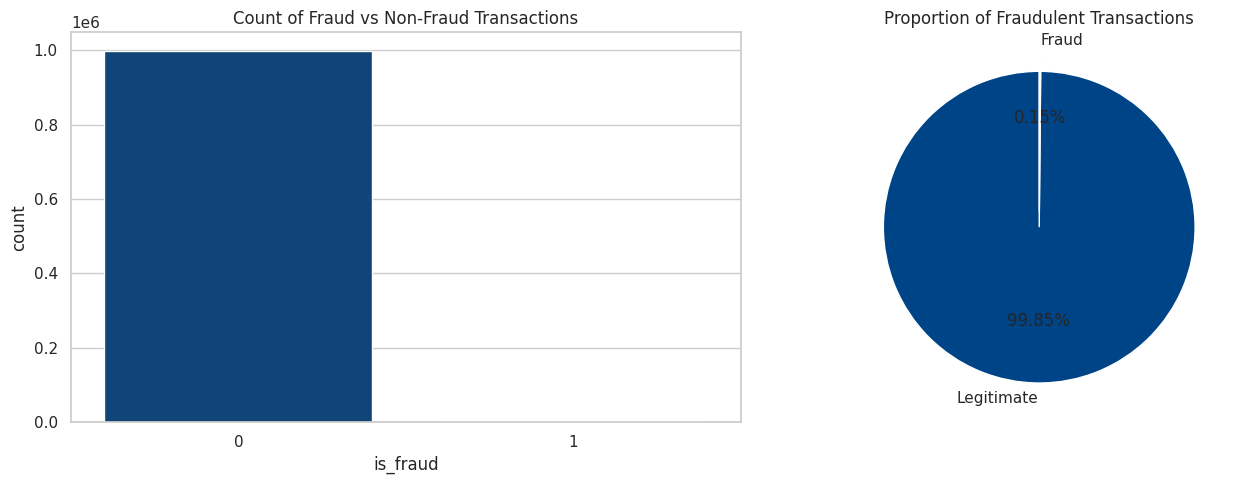

/tmp/ipykernel_24216/1823987307.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['is_fraud'] == 1], y='fraud_type', palette='viridis')


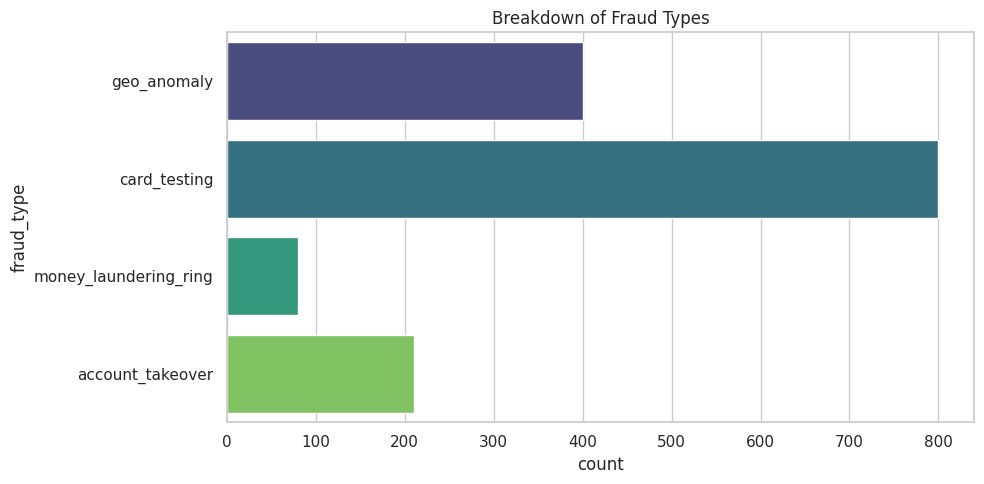


2. Numerical Distributions


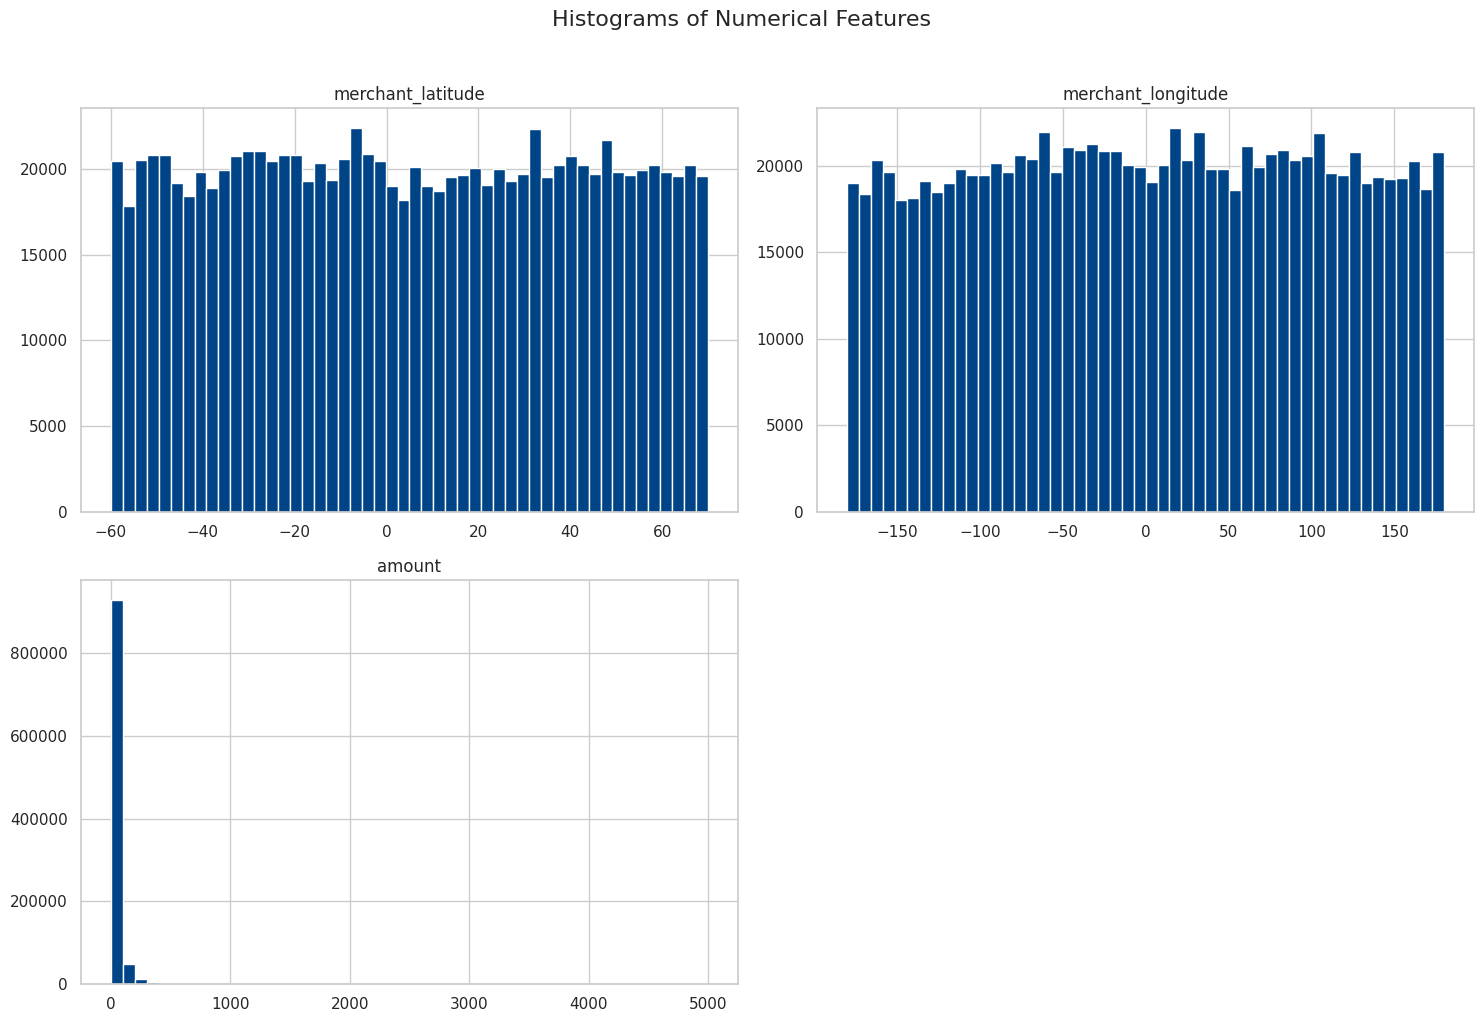

/tmp/ipykernel_24216/1823987307.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='is_fraud', y='amount', palette=['#004488', '#D95319'])


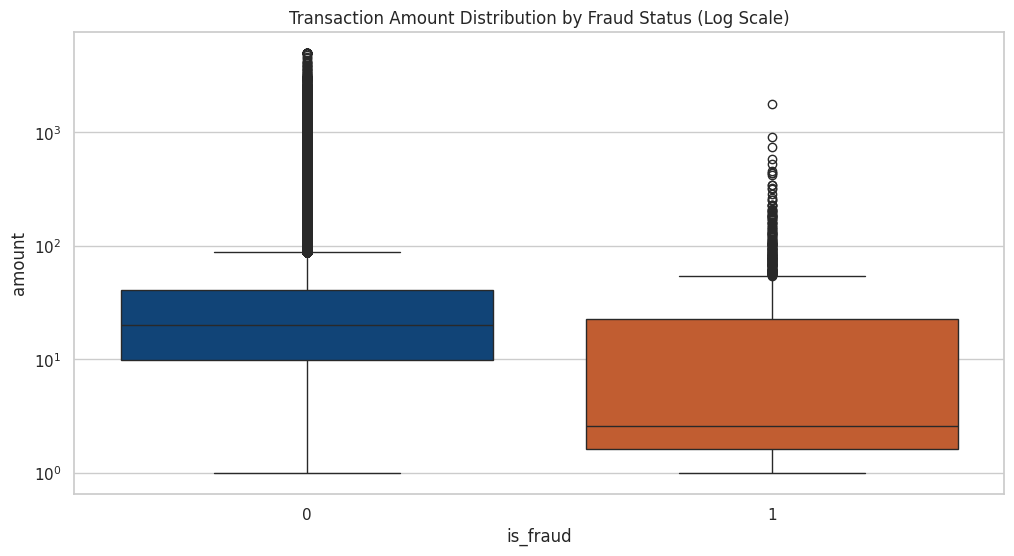


3. Categorical Distributions


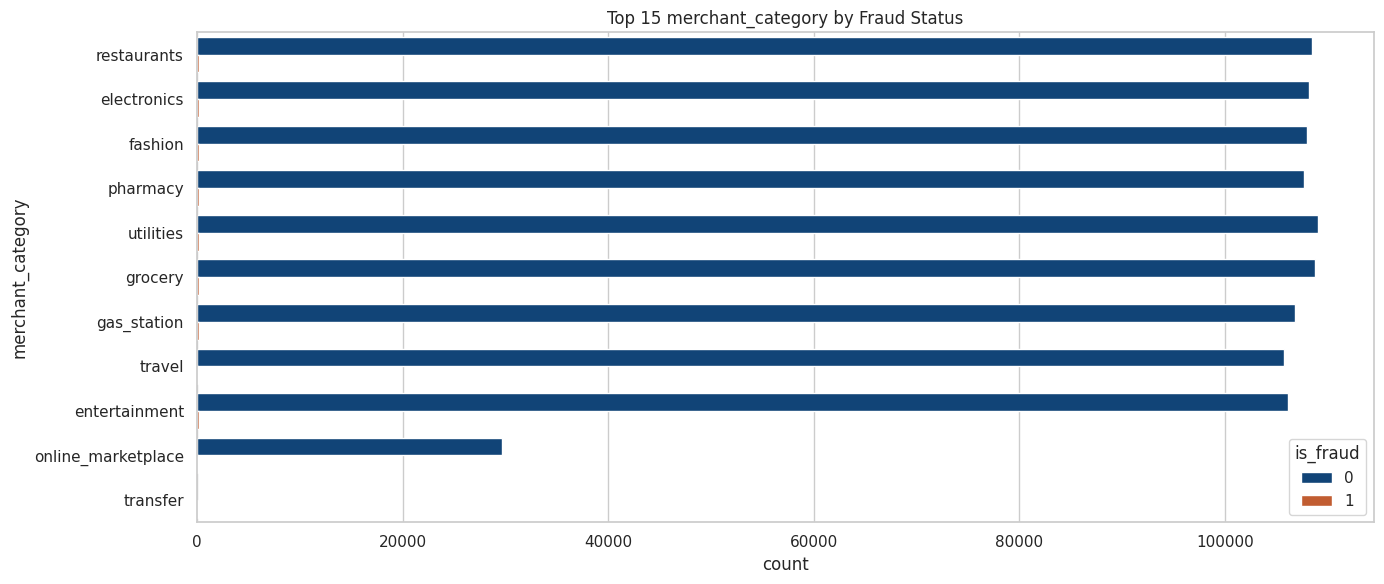

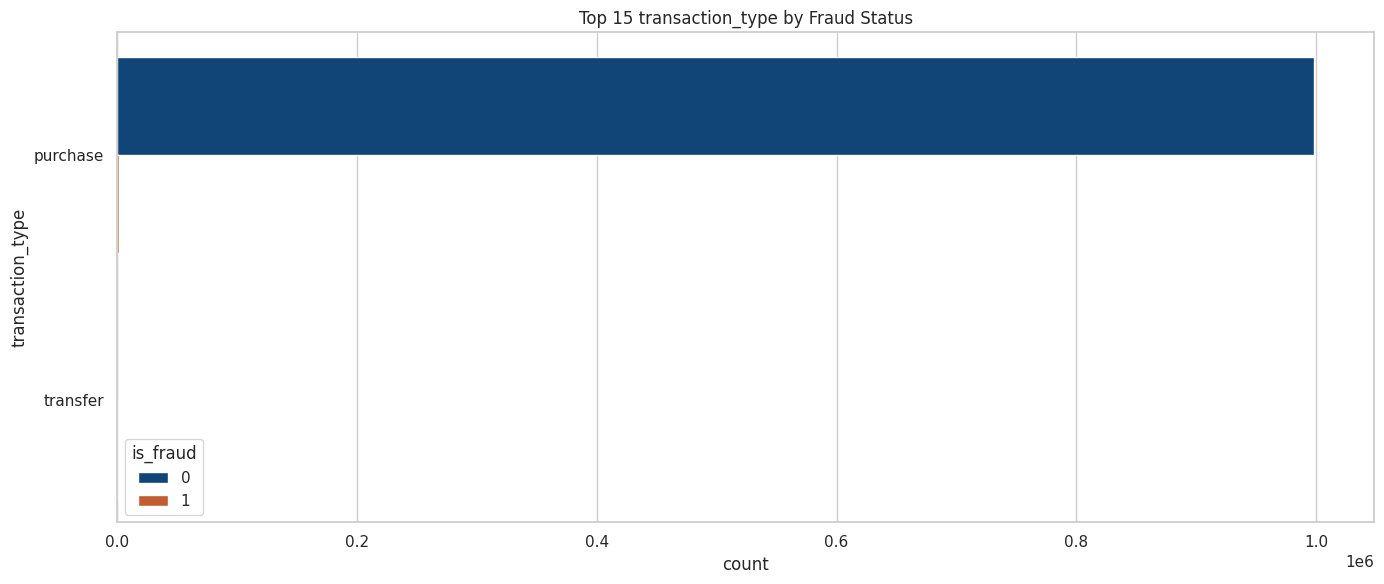

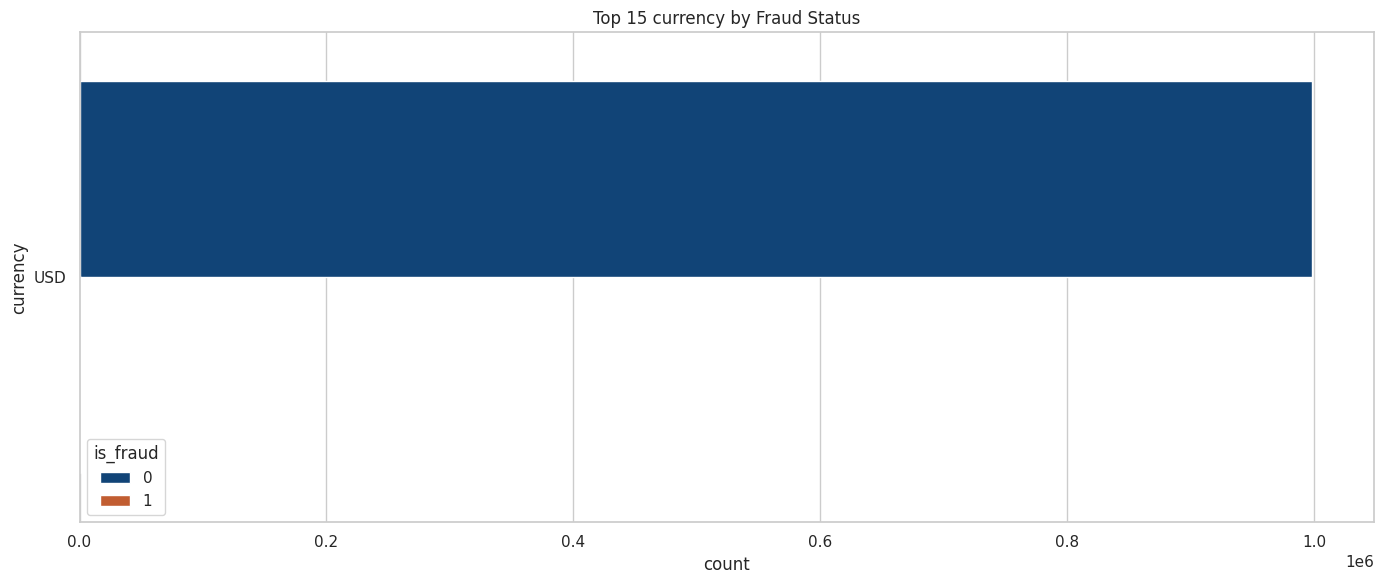


4. Correlation Matrix


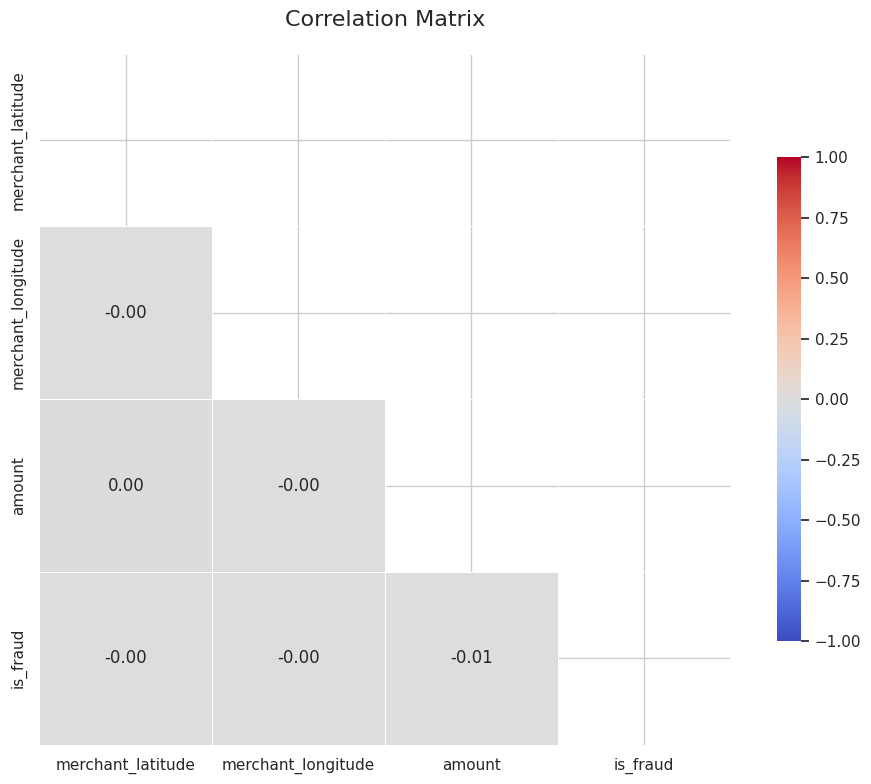


5. Statistical Significance vs Fraud
--- ANOVA: Numerical Features vs Fraud Status ---
           Feature  F-Statistic      P-Value
            amount    43.549156 4.136475e-11
 merchant_latitude     1.190434 2.752422e-01
merchant_longitude     0.160771 6.884479e-01

--- Chi-Squared: Categorical Features vs Fraud Status ---
          Feature  Chi2-Statistic  P-Value
merchant_category    53635.442003 0.000000
 transaction_type    52946.470391 0.000000
 merchant_country        4.875999 0.844981
         currency        0.000000 1.000000
       fraud_type        0.000000 1.000000


In [60]:
run_comprehensive_eda('/content/Fraud Detection Dataset.csv')

In [61]:
print(df.columns)

Index(['transaction_id', 'timestamp', 'customer_id', 'card_id', 'device_id',
       'ip_address', 'merchant_id', 'merchant_category', 'merchant_country',
       'merchant_city', 'merchant_latitude', 'merchant_longitude',
       'transaction_type', 'amount', 'currency', 'is_fraud', 'fraud_type'],
      dtype='object')


## Creacion de nuevas features

In [62]:
import pandas as pd
import numpy as np
import time

def preprocess_fraud_data_optimized(df):
    print("1. Parsing dates and sorting...")
    start_time = time.time()

    # Convert timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

    # Sort by customer_id and timestamp for features that depend on sequence within a customer
    # Make a copy to avoid modifying the original df for subsequent global sorting requirements
    df_for_customer_features = df.sort_values(by=['customer_id', 'timestamp']).reset_index(drop=True)

    print("2. Calculating temporal and geovelocity features...")
    df_for_customer_features['hour_of_day'] = df_for_customer_features['timestamp'].dt.hour
    df_for_customer_features['day_of_week'] = df_for_customer_features['timestamp'].dt.dayofweek
    df_for_customer_features['is_night_time'] = df_for_customer_features['hour_of_day'].between(1, 5).astype(int)

    # Time since last transaction
    df_for_customer_features['time_since_last_tx'] = df_for_customer_features.groupby('customer_id')['timestamp'].diff().dt.total_seconds().fillna(0)

    # Vectorized Haversine distance
    df_for_customer_features['prev_lat'] = df_for_customer_features.groupby('customer_id')['merchant_latitude'].shift()
    df_for_customer_features['prev_lon'] = df_for_customer_features.groupby('customer_id')['merchant_longitude'].shift()

    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        a = np.sin((lat2 - lat1)/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2.0)**2
        return 6371 * 2 * np.arcsin(np.sqrt(a))

    df_for_customer_features['distance_km'] = haversine(df_for_customer_features['merchant_latitude'], df_for_customer_features['merchant_longitude'], df_for_customer_features['prev_lat'], df_for_customer_features['prev_lon']).fillna(0)
    df_for_customer_features['geovelocity_kmh'] = df_for_customer_features['distance_km'] / ((df_for_customer_features['time_since_last_tx'] + 1) / 3600)
    df_for_customer_features.drop(columns=['prev_lat', 'prev_lon', 'distance_km'], inplace=True)

    df_for_customer_features['is_new_device'] = (df_for_customer_features.groupby(['customer_id', 'device_id']).cumcount() == 0).astype(int)

    # Now, assign the processed dataframe back to 'df' and prepare for rolling windows
    df = df_for_customer_features.copy() # All customer-sequence features are computed.

    print("3. Calculating rolling windows (Vectorized)...")

    # Crucial: Ensure the DataFrame is sorted by timestamp globally before setting as index for time-based rolling
    df = df.sort_values(by='timestamp').reset_index(drop=True)
    df = df.set_index('timestamp')

    # Grouping by customer_id after setting global monotonic timestamp index
    grouped_cust = df.groupby('customer_id')

    # Using pandas native cythonized rolling functions (No lambdas with apply)
    df['tx_count_1h'] = grouped_cust['amount'].transform(lambda x: x.rolling('1h').count())
    df['tx_count_24h'] = grouped_cust['amount'].transform(lambda x: x.rolling('24h').count())
    df['tx_amount_1h'] = grouped_cust['amount'].transform(lambda x: x.rolling('1h').sum())
    df['tx_amount_24h'] = grouped_cust['amount'].transform(lambda x: x.rolling('24h').sum())

    # Expanding historical average
    df['hist_avg_amount'] = grouped_cust['amount'].transform(lambda x: x.expanding().mean().shift().fillna(x))
    df['amount_to_avg_ratio'] = df['amount'] / (df['hist_avg_amount'] + 0.01)
    df.drop(columns=['hist_avg_amount'], inplace=True)

    # Fast device velocity (Replaces the slow unique cards logic)
    # Since the overall df index is now globally monotonic (sorted by timestamp),
    # the index within each device_id group will also be monotonic.
    df['device_tx_count_24h'] = df.groupby('device_id')['amount'].transform(lambda x: x.rolling('24h').count())

    df = df.reset_index()

    print("4. Cleaning up and formatting for XGBoost...")
    cols_to_drop = [
        'transaction_id', 'customer_id', 'card_id', 'device_id', 'ip_address',
        'merchant_id', 'fraud_type', 'currency', 'merchant_latitude',
        'merchant_longitude'
    ]

    df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

    # Encode Categories
    cat_cols = ['merchant_category', 'merchant_country', 'merchant_city', 'transaction_type']
    for col in cat_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype('category')

    print(f"Done in {time.time() - start_time:.2f} seconds!")
    return df_clean

# Run the pipeline
df_processed = preprocess_fraud_data_optimized(df)

1. Parsing dates and sorting...
2. Calculating temporal and geovelocity features...
3. Calculating rolling windows (Vectorized)...
4. Cleaning up and formatting for XGBoost...
Done in 549.65 seconds!


## Train / test split

In [64]:
import pandas as pd

def perform_temporal_split(df, target_col='is_fraud'):
    # 1. Global Time Sort
    # The previous preprocessing sorted by customer_id first. We must resort globally
    # by timestamp to ensure a strict chronological timeline for the whole dataset.
    if 'timestamp' not in df.columns:
        raise ValueError("The 'timestamp' column is required for a temporal split. Ensure it is not dropped during preprocessing.")

    df_sorted = df.sort_values(by='timestamp').reset_index(drop=True)

    # 2. Calculate Split Indices (60% Train / 20% Test / 20% Validation)
    n_total = len(df_sorted)
    train_end = int(n_total * 0.60)
    test_end = int(n_total * 0.80)

    # 3. Slice the DataFrame
    train_df = df_sorted.iloc[:train_end]
    test_df = df_sorted.iloc[train_end:test_end]
    val_df = df_sorted.iloc[test_end:]

    # 4. Separate Features (X) and Target (y), and drop the timestamp
    X_train = train_df.drop(columns=[target_col, 'timestamp'])
    y_train = train_df[target_col]

    X_test = test_df.drop(columns=[target_col, 'timestamp'])
    y_test = test_df[target_col]

    X_val = val_df.drop(columns=[target_col, 'timestamp'])
    y_val = val_df[target_col]

    print(f"Total records: {n_total}")
    print(f"Training set:   {len(X_train)} rows (0% - 60%)")
    print(f"Testing set:    {len(X_test)} rows (60% - 80%)")
    print(f"Validation set: {len(X_val)} rows (80% - 100%)")

    return X_train, y_train, X_test, y_test, X_val, y_val

X_train, y_train, X_test, y_test, X_val, y_val = perform_temporal_split(df_processed, 'is_fraud')

Total records: 1000000
Training set:   600000 rows (0% - 60%)
Testing set:    200000 rows (60% - 80%)
Validation set: 200000 rows (80% - 100%)


## Encoding de las variables categoricas

In [65]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

def encode_categorical_features(df, target_col='is_fraud'):
    # Separate features and target
    y = df[target_col] if target_col in df.columns else None
    X = df.drop(columns=[target_col]) if target_col in df.columns else df.copy()

    # Automatically identify categorical and numerical columns
    cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()

    # Configure the OneHotEncoder
    # - handle_unknown='ignore': Prevents errors if new cities/categories appear in future data
    # - sparse_output=False: Returns a dense array, required for smooth pandas integration
    # - min_frequency=0.01: Groups any category representing less than 1% of the data into an 'infrequent' column
    categorical_transformer = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        min_frequency=0.01
    )

    # Build the ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', categorical_transformer, cat_cols),
            ('num', 'passthrough', num_cols)
        ],
        remainder='drop' # Drops any columns not explicitly handled
    )

    # Force scikit-learn to output a Pandas DataFrame with proper column names
    preprocessor.set_output(transform="pandas")

    # Fit and transform the data
    X_encoded = preprocessor.fit_transform(X)

    # Reattach the target variable
    if y is not None:
        X_encoded[target_col] = y.values

    return X_encoded, preprocessor

# 1. Fit the encoder ONLY on the training data
X_train_encoded, fitted_encoder = encode_categorical_features(X_train, target_col=None)
print(f'Tamaño de X_train_encoded: {X_train_encoded.shape}')

# 2. Transform the test and validation data using the existing fitted_encoder
X_test_encoded = fitted_encoder.transform(X_test)
print(f'Tamaño de X_test_encoded: {X_test_encoded.shape}')

X_val_encoded = fitted_encoder.transform(X_val)
print(f'Tamaño de X_val_encoded: {X_val_encoded.shape}')

Tamaño de X_train_encoded: (600000, 37)
Tamaño de X_test_encoded: (200000, 37)
Tamaño de X_val_encoded: (200000, 37)


## Entrenamiento del modelo

In [67]:
import lightgbm as lgb

print("New Label Distribution in Training:")
print(y_train.value_counts(normalize=True))

# Initialize and fit LightGBM
model_lgb = lgb.LGBMClassifier(
    class_weight = 'balanced',
    objective='binary',
    metric='binary_logloss',
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_lgb.fit(
    X_train_encoded, y_train,
    eval_set=[(X_val_encoded, y_val)],
    callbacks=[lgb.early_stopping(10)]
)

preds_lgb = model_lgb.predict(X_test_encoded)
print("\nLightGBM Model Training Complete with balanced data.")

New Label Distribution in Training:
is_fraud
0    0.998503
1    0.001497
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 898, number of negative: 599102
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1622
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.184829

LightGBM Model Training Complete with balanced data.


LightGBM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    199685
           1       0.10      0.66      0.17       315

    accuracy                           0.99    200000
   macro avg       0.55      0.83      0.58    200000
weighted avg       1.00      0.99      0.99    200000



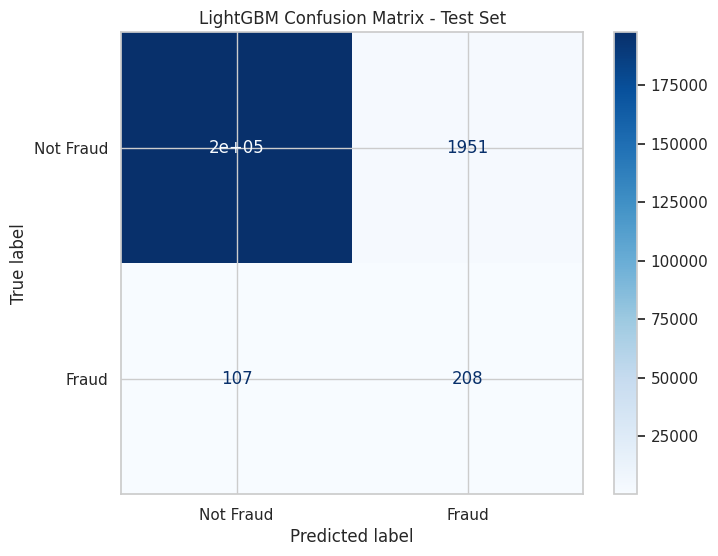

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate classification report
print("LightGBM Classification Report:")
print(classification_report(y_test, preds_lgb))

# Calculate and plot the confusion matrix
cm = confusion_matrix(y_test, preds_lgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('LightGBM Confusion Matrix - Test Set')
plt.show()

[LightGBM] [Info] Number of positive: 898, number of negative: 599102
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1622
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


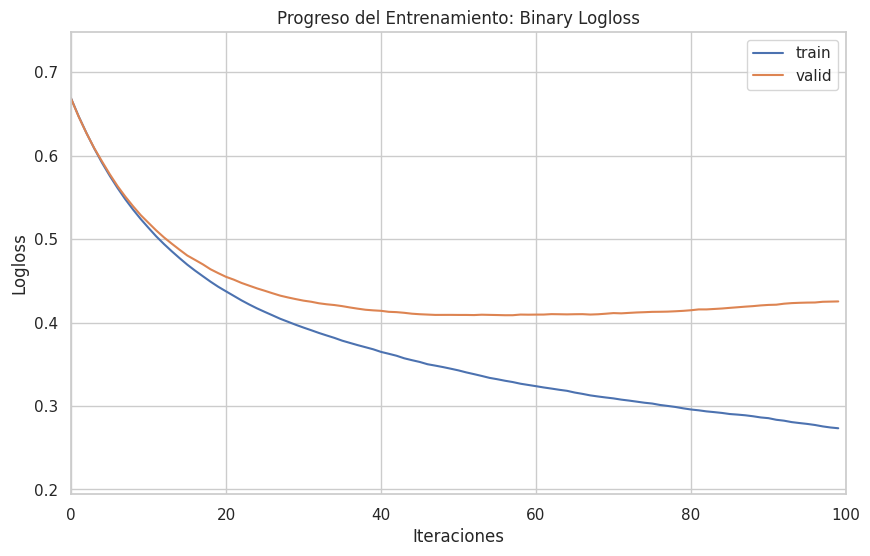

In [69]:
from sklearn.utils.class_weight import compute_sample_weight

# Calculate weights for both sets manually
train_weights = compute_sample_weight('balanced', y_train)
val_weights = compute_sample_weight('balanced', y_val)

evals_result = {}

model_lgb.fit(
    X_train_encoded, y_train,
    eval_set=[(X_train_encoded, y_train), (X_val_encoded, y_val)],
    eval_names=['train', 'valid'],
    eval_sample_weight=[train_weights, val_weights], # Apply weights to both
    callbacks=[lgb.record_evaluation(evals_result)]
)

# Graficar el logloss
ax = lgb.plot_metric(evals_result, metric='binary_logloss', figsize=(10, 6))
plt.title('Progreso del Entrenamiento: Binary Logloss')
plt.xlabel('Iteraciones')
plt.ylabel('Logloss')
plt.grid(True)
plt.show()

# Quitarle overfitting

## Tuneo de hyperparametros

In [70]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import contextlib
import joblib
from tqdm.auto import tqdm

# 1. Context Manager to link scikit-learn's parallel backend with tqdm
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# 2. Hyperparameter Grid
param_distributions = {
    'num_leaves': [15, 20, 31],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [50, 100, 200],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0.1, 0.5, 1.0, 5.0],
    'reg_lambda': [0.1, 0.5, 1.0, 5.0]
}

# 3. Base Model
lgb_base = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores
)

# 4. RandomizedSearchCV Setup
n_iterations = 20
cv_folds = 3

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_distributions,
    n_iter=n_iterations,
    scoring='recall', # Optimizing to reduce False Negatives
    cv=cv_folds,
    verbose=0, # Set to 0 so sklearn's text output doesn't break the progress bar visual
    random_state=42,
    n_jobs=-1
)

# 5. Execute with Progress Bar
total_fits = n_iterations * cv_folds
print(f"Starting Grid Search: Training {total_fits} total models...")

# Wrap the fit step in the joblib+tqdm context manager
with tqdm_joblib(tqdm(desc="Tuning Progress", total=total_fits)):
    random_search.fit(
        X_train_encoded, y_train,
        eval_set=[(X_val_encoded, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
    )

# 6. Results
optimal_lgb_model = random_search.best_estimator_
print("\n=== Tuning Complete ===")
print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best Cross-Validated Recall Score: {random_search.best_score_:.4f}")

preds_optimal = optimal_lgb_model.predict(X_test_encoded)

Starting Grid Search: Training 60 total models...


Tuning Progress:   0%|          | 0/60 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 898, number of negative: 599102
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1616
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

## Grafica del modelo tuneado

In [71]:
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_and_plot_cm(y_true, y_pred, title='LightGBM Confusion Matrix - Test Set'):
    """
    Prints the classification report and plots the confusion matrix.
    """
    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Calculate and plot the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax)
    plt.title(title)
    plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    199685
           1       0.04      0.73      0.07       315

    accuracy                           0.97    200000
   macro avg       0.52      0.85      0.53    200000
weighted avg       1.00      0.97      0.98    200000



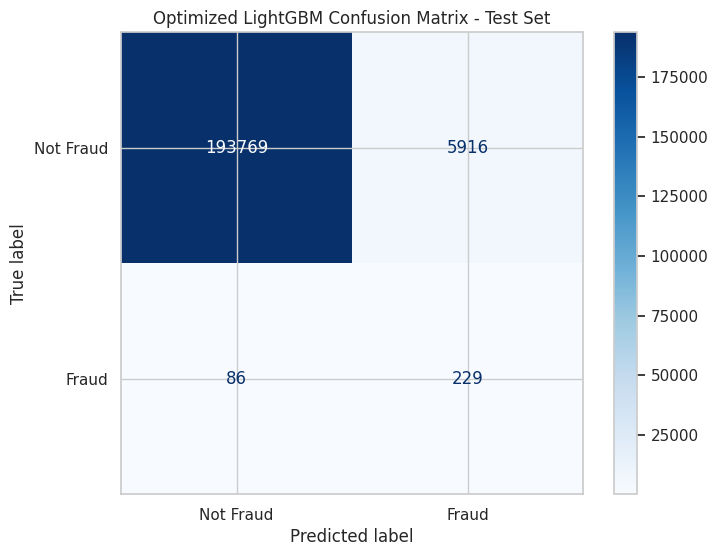

In [72]:
# Print the classification report and plot the confusion matrix
# Note: Ensure you use 'preds_optimal' if you want to evaluate the newly tuned model,
# or 'preds_lgb' if you are evaluating the base model.
evaluate_and_plot_cm(y_test, preds_optimal, title='Optimized LightGBM Confusion Matrix - Test Set')

[LightGBM] [Info] Number of positive: 898, number of negative: 599102
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094711 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1616
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

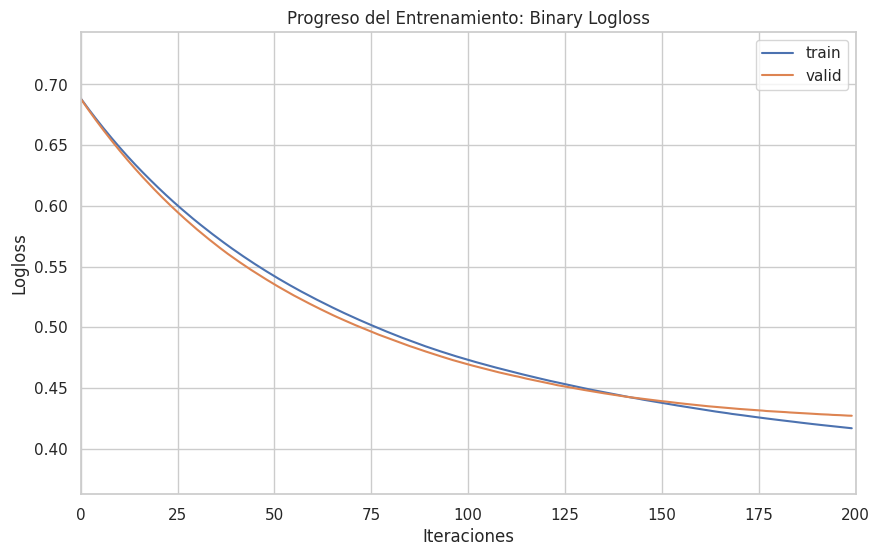

In [73]:
from sklearn.utils.class_weight import compute_sample_weight

# Calculate weights for both sets manually
train_weights = compute_sample_weight('balanced', y_train)
val_weights = compute_sample_weight('balanced', y_val)

evals_result = {}

optimal_lgb_model.fit(
    X_train_encoded, y_train,
    eval_set=[(X_train_encoded, y_train), (X_val_encoded, y_val)],
    eval_names=['train', 'valid'],
    eval_sample_weight=[train_weights, val_weights], # Apply weights to both
    callbacks=[lgb.record_evaluation(evals_result)]
)

# Graficar el logloss
ax = lgb.plot_metric(evals_result, metric='binary_logloss', figsize=(10, 6))
plt.title('Progreso del Entrenamiento: Binary Logloss')
plt.xlabel('Iteraciones')
plt.ylabel('Logloss')
plt.grid(True)
plt.show()

## Regresion para otbener probabilidades de obtener un fraude.

In [74]:
import pandas as pd

# Generate the probability array
# predict_proba returns a 2D array with two columns:
# Column 0: Probability of Class 0 (Not Fraud)
# Column 1: Probability of Class 1 (Fraud)
probabilities = optimal_lgb_model.predict_proba(X_test_encoded)

# Convert the array into a clean DataFrame for easy analysis
prob_df = pd.DataFrame(probabilities, columns=['Prob_Not_Fraud', 'Prob_Fraud'])

# Attach the hard predictions and actual true labels for comparison
prob_df['Predicted_Class'] = optimal_lgb_model.predict(X_test_encoded)
prob_df['True_Label'] = y_test.values

# Display the first few rows
print(prob_df.head(10))

   Prob_Not_Fraud  Prob_Fraud  Predicted_Class  True_Label
0        0.693523    0.306477                0           0
1        0.771472    0.228528                0           0
2        0.779574    0.220426                0           0
3        0.694425    0.305575                0           0
4        0.749380    0.250620                0           0
5        0.734294    0.265706                0           0
6        0.756668    0.243332                0           0
7        0.357875    0.642125                1           0
8        0.761336    0.238664                0           0
9        0.931046    0.068954                0           0


## Exportar a formato joblib

In [75]:
import joblib

# Export the model to a file
joblib.dump(optimal_lgb_model, 'fraud_detection_model.joblib')

['fraud_detection_model.joblib']

In [76]:
import joblib

# Load the model inside your API
loaded_model = joblib.load('fraud_detection_model.joblib')

# Example usage in the API
# predictions = loaded_model.predict(new_data)
# probabilities = loaded_model.predict_proba(new_data)

## Joblib con autoencoder

In [77]:
import joblib
import lightgbm as lgb

# 1. Bundle the fitted encoder, the trained model, and the library version
pipeline_artifacts = {
    'encoder': fitted_encoder,
    'model': optimal_lgb_model, # Use optimal_lgb_model if you didn't rename it after Random Search
    'lgbm_version': lgb.__version__
}

# 2. Export to a single joblib file
joblib.dump(pipeline_artifacts, 'fraud_detection_pipeline_v1.joblib')

print(f"Pipeline successfully exported!")
print(f"LightGBM Version recorded: {pipeline_artifacts['lgbm_version']}")

Pipeline successfully exported!
LightGBM Version recorded: 4.6.0


In [78]:
import sys
import pkg_resources

# List of libraries used in the project
libraries = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scipy', 'scikit-learn', 'lightgbm', 'joblib', 'tqdm'
]

print("# Environment Versions:")
print(f"# Python Version: {sys.version.split()[0]}")

for lib in libraries:
    try:
        version = pkg_resources.get_distribution(lib).version
        print(f"# {lib}=={version}")
    except pkg_resources.DistributionNotFound:
        print(f"# {lib} is not installed")

# Environment Versions:
# Python Version: 3.13.15
# pandas==2.2.3
# numpy==2.1.3
# matplotlib==3.10.0
# seaborn==0.13.2
# scipy==1.16.3
# scikit-learn==1.6.1
# lightgbm==4.6.0
# joblib==1.6.0
# tqdm==4.67.3


/tmp/ipykernel_24216/791400325.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
